# İstanbul için derin öğrenme ile günlük yağış ölçek küçültme

**Kapsam:** Mevcut Ocak–Mart 1981 ERA5 ve ERA5-Land verileriyle tekrarlanabilir bir yöntem denemesi.
Bu notebook geleceğin iklimini tahmin etmez; geçmiş atmosfer alanlarından aynı günün yerel yağışını kestirir.

Özgün çalışma: Jose González-Abad / Climate Change AI, *Statistical Downscaling of Climate Projections with Deep Learning* (2026), MIT lisansı.
İstanbul uyarlaması ERA5 girdileri ve ERA5-Land referansı kullanır. Özgün Yeni Zelanda sonuçları bu bölgeye aktarılmamıştır.

**Çalıştırma:** Proje klasörünü aç, mevcut `.venv` kernel'ini seç ve **Restart Kernel → Run All** çalıştır.
Notebook ağ isteği veya paket kurulumu yapmaz. Gerekirse ortamı önce `python -m pip install -r requirements.txt` ile hazırla.
Veri/model yardımcıları [istanbul_downscaling.py](istanbul_downscaling.py) içindedir.


In [1]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.


## 1. Deney tasarımı ve ayarlar

| Küme | UTC günleri | Kullanımı |
|---|---|---|
| Eğitim | 1–31 Ocak 1981 | Normalizasyon, başlangıç ortalaması ve ağırlıklar |
| Doğrulama | 1–28 Şubat 1981 | En iyi epoch seçimi ve erken durdurma |
| Bağımsız test | 1–30 Mart 1981 | Model seçimi bittikten sonra değerlendirme |

31 Mart toplam yağışı için **1 Nisan 00 UTC** kaydı gerekir; mevcut dosyalarda bulunmadığı için o gün değerlendirilmez.
Ocak ve Şubat son günleri sonraki ayın ilk 00 UTC kaydıyla tamamlanır.
Test sonuçlarına bakarak ayarları tekrar tekrar değiştirmek bu testin bağımsızlığını bozar.

Üç ay, mevsimsel genelleme veya iklim değişimi hakkında sonuç çıkarmaya yetmez. Eğitim ve test farklı aylardan olduğu için mevsimsel dağılım değişimi de bu kısa deneyi etkiler.


In [2]:
from pathlib import Path
import hashlib
import json
import random
import time

import numpy as np
import pandas as pd
import xarray as xr
import torch
import matplotlib.pyplot as plt
from IPython.display import display

from istanbul_downscaling import (
    PRED_VARS, DeepESD, prepare_daily, split_periods, fit_preprocessor,
    train_model, downscale, baseline_predictions, summarize,
    save_checkpoint, load_checkpoint,
)

DATA_ROOT = Path('IST_domain')
MONTHS = ['1981_01', '1981_02', '1981_03']
PERIODS = {
    'train': ['1981-01-01', '1981-01-31'],
    'validation': ['1981-02-01', '1981-02-28'],
    'test': ['1981-03-01', '1981-03-30'],
}
SEED = 0
DEVICE = 'cpu'  # Küçük deney; aynı CPU akışıyla tekrarlanabilir karşılaştırma.
MAX_EPOCHS = 200
PATIENCE = 25
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
FILTERS_LAST_CONV = 4
WET_DAY_THRESHOLD = 1.0  # mm/gün
TRACK_EMISSIONS = False  # İsteğe bağlı: codecarbon gerekir; Türkiye için çevrimdışı tahmin.

RUN_NAME = 'istanbul_1981_q1'
RESULTS_DIR = Path('results') / RUN_NAME
PREPARED_DIR = DATA_ROOT / 'prepared' / RUN_NAME
MODEL_PATH = Path('models') / f'deepesd_{RUN_NAME}.pt'
POINTS = [
    {'name': 'Sarıyer', 'lat': 41.17, 'lon': 29.05},
    {'name': 'Kadıköy', 'lat': 40.99, 'lon': 29.03},
]
for directory in [RESULTS_DIR, PREPARED_DIR, MODEL_PATH.parent]:
    directory.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
print(f'PyTorch {torch.__version__} | cihaz: {DEVICE} | seed: {SEED}')


PyTorch 2.8.0 | cihaz: cpu | seed: 0


## 2. Ham veriden günlük girdiye ve hedefe

- ERA5: `u`, `v`, `q`, `t`, `z`; 850/700/500 hPa; 00/06/12/18 UTC örneklerinin günlük ortalaması.
- ERA5-Land: ertesi günün 00 UTC `tp` birikimi × 1.000 = önceki UTC gününün toplam yağışı, mm/gün.
- `tasmax`: o UTC gününün 24 saatlik `t2m` örneklerinin maksimumu − 273,15; bu deneyde eğitimin hedefi yalnız yağıştır.
- Enlemler artan sıraya alınır; girdi ve hedef farklı çözünürlüklerini korur. Yalnız zaman ekseni eşleştirilir.

Eksik ham saatler, yinelenen tarihler, değişen ızgaralar ve beklenmeyen birimler hata üretir.
Gün içindeki birikimli yağış saatlerini toplamak yanlış olur.
[ECMWF günlük birikim açıklaması](https://confluence.ecmwf.int/spaces/CKB/pages/462888259/ERA5%2Bfamily%2Bpost-processed%2Bdaily%2Bstatistics%2Bdocumentation).


In [3]:
predictor_files = [DATA_ROOT / 'raw' / 'era5_monthly' / f'ERA5_{month}.nc' for month in MONTHS]
target_files = [DATA_ROOT / 'raw' / 'era5_land_monthly' / f'ERA5_Land_{month}.nc' for month in MONTHS]
predictors, targets, data_audit = prepare_daily(predictor_files, target_files)

print('Ortak tam günler:', data_audit['days'], data_audit['start'], '→', data_audit['end'])
print('Hedefi tamamlanamadığı için dışarıda kalan günler:', data_audit['excluded_predictor_dates'])
print('Predictor boyutları:', dict(predictors.sizes))
print('Hedef boyutları:', dict(targets.sizes))
print('Girdi alanları:', list(predictors.data_vars))

predictors.to_netcdf(PREPARED_DIR / 'predictors_daily.nc')
targets.to_netcdf(PREPARED_DIR / 'targets_daily.nc')
(RESULTS_DIR / 'data_audit.json').write_text(json.dumps(data_audit, ensure_ascii=False, indent=2))


Ortak tam günler: 89 1981-01-01 → 1981-03-30
Hedefi tamamlanamadığı için dışarıda kalan günler: ['1981-03-31']
Predictor boyutları: {'time': 89, 'lat': 7, 'lon': 13}
Hedef boyutları: {'lat': 16, 'lon': 31, 'time': 89}
Girdi alanları: ['u_850', 'u_700', 'u_500', 'v_850', 'v_700', 'v_500', 'q_850', 'q_700', 'q_500', 't_850', 't_700', 't_500', 'z_850', 'z_700', 'z_500']


## 3. Zaman ayrımı, kara maskesi ve normalizasyon

Normalizasyon ve geçerli hedef maskesi **yalnız Ocak eğitim verisinden** hesaplanır.
Her değişkenin her ızgara hücresi için zaman ortalaması ve standart sapması kullanılır.
Şubat ve Mart aynı istatistiklerle dönüştürülür; yeni bir normalizasyon öğrenilmez.

ERA5-Land bu kutuda deniz hücrelerini NaN olarak verir. Bunlar eğitimden çıkarılır, sonuç haritalarında NaN olarak kalır.
Geçerli bir kara hücresinde eksik değer varsa günü veya hücreyi sessizce silmek yerine hata verilir.


In [4]:
splits = split_periods(predictors, targets['pr'], PERIODS)
train_predictors, train_reference = splits['train']
validation_predictors, validation_reference = splits['validation']
test_predictors, test_reference = splits['test']

preprocessor = fit_preprocessor(train_predictors, train_reference)
x_train = preprocessor.inputs(train_predictors)
y_train = preprocessor.targets(train_reference)
x_validation = preprocessor.inputs(validation_predictors)
y_validation = preprocessor.targets(validation_reference)
# Test verisi burada eğitime veya model seçimine verilmez.

print('Eğitim:', x_train.shape, '→', y_train.shape)
print('Doğrulama:', x_validation.shape, '→', y_validation.shape)
print('Test için ayrılan gün:', test_predictors.sizes['time'])
print('Geçerli hedef hücreleri:', int(preprocessor.land_mask.sum()))
print('Maskelenen hücreler:', int((~preprocessor.land_mask).sum()))


Eğitim: (31, 15, 7, 13) → (31, 210)
Doğrulama: (28, 15, 7, 13) → (28, 210)
Test için ayrılan gün: 30
Geçerli hedef hücreleri: 210
Maskelenen hücreler: 286


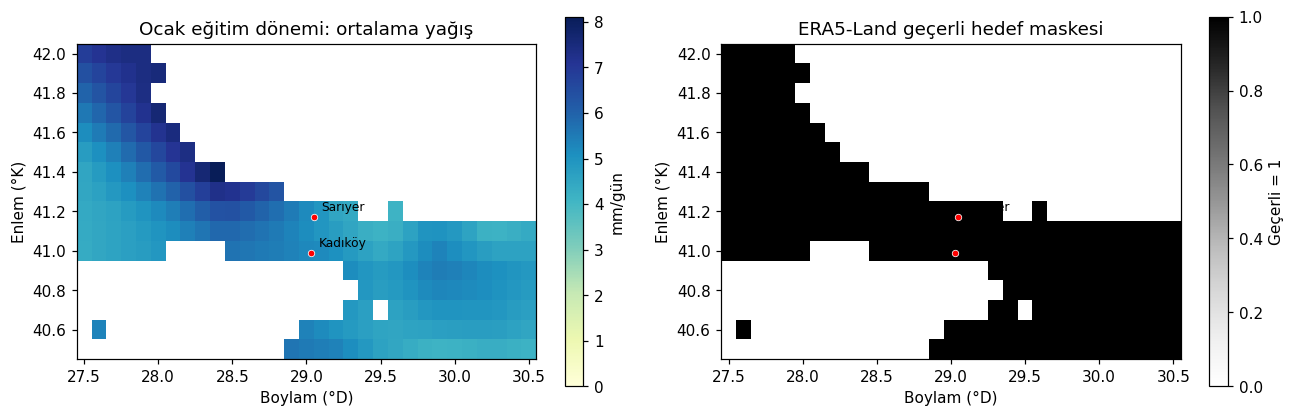

,nokta,hedef_enlem,hedef_boylam,geçerli
0,Sarıyer,41.2,29.0,True
1,Kadıköy,41.0,29.0,True


In [5]:
# Haritalar için ağ erişimi gerektirmeyen koordinat çizimi.
def plot_field(ax, field, title, *, cmap='YlGnBu', vmin=None, vmax=None, label='mm/gün'):
    mesh = ax.pcolormesh(field.lon, field.lat, field.transpose('lat', 'lon'),
                         shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set(xlabel='Boylam (°D)', ylabel='Enlem (°K)', title=title)
    ax.set_aspect(1 / np.cos(np.deg2rad(float(field.lat.mean()))))
    for point in POINTS:
        ax.scatter(point['lon'], point['lat'], s=18, color='red', edgecolor='white', linewidth=.5)
        ax.annotate(point['name'], (point['lon'], point['lat']), xytext=(5, 4),
                    textcoords='offset points', fontsize=8)
    plt.colorbar(mesh, ax=ax, label=label, shrink=.8)
    return mesh

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_field(axes[0], train_reference.mean('time'), 'Ocak eğitim dönemi: ortalama yağış', vmin=0)
plot_field(axes[1], preprocessor.land_mask.astype(int), 'ERA5-Land geçerli hedef maskesi',
           cmap='Greys', vmin=0, vmax=1, label='Geçerli = 1')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'training_domain.png', dpi=160, bbox_inches='tight')
plt.show()

# Şehir noktalarının gerçekte hangi model hücrelerinden örneklendiğini görünür tut.
rows = []
for point in POINTS:
    selected = train_reference.sel(lat=point['lat'], lon=point['lon'], method='nearest')
    rows.append({'nokta': point['name'], 'hedef_enlem': float(selected.lat),
                 'hedef_boylam': float(selected.lon), 'geçerli': bool(selected.notnull().all())})
display(pd.DataFrame(rows))


## 4. DeepESD eğitimi ve doğrulamayla model seçimi

Üç konvolüsyon ve son tam bağlantılı katman, `(15, 7, 13)` girdisini 210 geçerli yağış hücresine dönüştürür.
Bu uyarlamada **LeakyReLU** dar son konvolüsyonda sıfır gradyan riskini azaltır; **Softplus** çıktıyı negatif olmaktan korur.
Son katman yalnız eğitim günlerinin hücre ortalaması çevresinde başlatılır. Kayıp, mm/gün cinsinden ham yağış üzerinde MSE'dir.

En fazla `MAX_EPOCHS` çalışır; doğrulama kaybı `PATIENCE` epoch iyileşmezse durur.
En iyi doğrulama ağırlıkları geri yüklenir; başlangıç hali de adaydır. Test ayı bu seçime katılmaz.
Ham yağış üzerinde MSE, yağışlı gün sıklığını ve uç değerleri iyi öğrenmeyi garanti etmez.


In [6]:
# Bu hücre tekrar çalıştırılırsa aynı başlangıç elde edilir.
torch.manual_seed(SEED)
model = DeepESD(
    n_predictors=len(PRED_VARS), n_outputs=y_train.shape[1],
    in_hw=x_train.shape[-2:], filters_last_conv=FILTERS_LAST_CONV,
)
model.initialize_from_mean(y_train.mean(axis=0))
print(model)
print('Parametre sayısı:', sum(p.numel() for p in model.parameters()))
print('Bir epoch içindeki batch sayısı:', int(np.ceil(len(x_train) / BATCH_SIZE)))

tracker = None
emissions_kg = None
if TRACK_EMISSIONS:
    from codecarbon import OfflineEmissionsTracker
    Path('code_carbon').mkdir(exist_ok=True)
    tracker = OfflineEmissionsTracker(
        country_iso_code='TUR', project_name=RUN_NAME, output_dir='code_carbon',
        output_file=f'{RUN_NAME}_emissions.csv', log_level='error',
    )
    tracker.start()
started = time.perf_counter()
try:
    history, training_info = train_model(
        model, x_train, y_train, x_validation, y_validation,
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE,
        patience=PATIENCE, seed=SEED, device=DEVICE,
    )
finally:
    if tracker is not None:
        emissions_kg = tracker.stop()
training_seconds = time.perf_counter() - started
print('Model seçimi:', training_info)
print(f'Eğitim süresi: {training_seconds:.2f} saniye')
if emissions_kg is not None:
    print(f'Çevrimdışı emisyon tahmini: {emissions_kg:.6f} kg CO₂e')
history.to_csv(RESULTS_DIR / 'training_history.csv', index=False)


DeepESD(
  (features): Sequential(
    (0): Conv2d(15, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.1)
    (2): Conv2d(50, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.1)
    (4): Conv2d(25, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.1)
  )
  (out): Linear(in_features=364, out_features=210, bias=True)
)
Parametre sayısı: 95629
Bir epoch içindeki batch sayısı: 2
Epoch   1: train MSE=51.378, validation MSE=63.169
Epoch  25: train MSE=10.917, validation MSE=39.927
Epoch  50: train MSE=3.445, validation MSE=28.833
Epoch  75: train MSE=2.193, validation MSE=30.200
Model seçimi: {'best_epoch': 60, 'best_validation_mse': 27.76311683654785, 'initial_validation_mse': 63.48381042480469, 'epochs_run': 85}
Eğitim süresi: 1.01 saniye


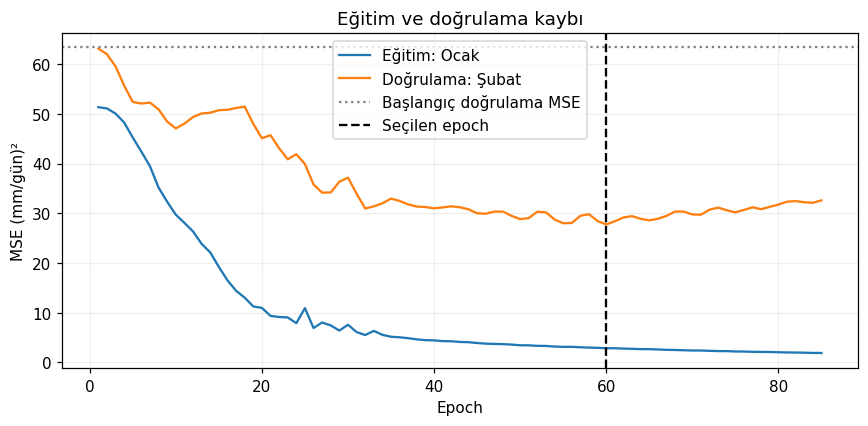

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.epoch, history.train_mse, label='Eğitim: Ocak')
ax.plot(history.epoch, history.validation_mse, label='Doğrulama: Şubat')
ax.axhline(training_info['initial_validation_mse'], color='grey', linestyle=':', label='Başlangıç doğrulama MSE')
ax.axvline(training_info['best_epoch'], color='black', linestyle='--', label='Seçilen epoch')
ax.set(xlabel='Epoch', ylabel='MSE (mm/gün)²', title='Eğitim ve doğrulama kaybı')
ax.grid(alpha=.2)
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'training_loss.png', dpi=160)
plt.show()


## 5. Yeniden kullanılabilir model kaydı

Ağırlıklarla birlikte değişken sırası ve birimleri, girdi/hedef koordinatları, kara maskesi,
normalizasyon istatistikleri, dönemler, ayarlar ve veri dosyası özetleri saklanır.
Yeni model `deepesd_istanbul_1981_q1.pt` olarak yazılır; önceki `deepesd_pr_istanbul.pt` dosyasının üzerine yazılmaz.
Bir sonraki hücre dosyayı yeniden yükleyip doğrulama tahminlerinin eşitliğini denetler.


In [8]:
source_hashes = {str(p): hashlib.sha256(p.read_bytes()).hexdigest() for p in predictor_files + target_files}
metadata = {
    'run_name': RUN_NAME, 'periods': PERIODS, 'data_audit': data_audit,
    'source_sha256': source_hashes,
    'implementation_sha256': hashlib.sha256(Path('istanbul_downscaling.py').read_bytes()).hexdigest(),
    'seed': SEED, 'max_epochs': MAX_EPOCHS, 'patience': PATIENCE,
    'batch_size': BATCH_SIZE, 'learning_rate': LEARNING_RATE,
    'wet_day_threshold': WET_DAY_THRESHOLD, 'training': training_info,
    'training_seconds': training_seconds,
    'torch_version': str(torch.__version__), 'numpy_version': np.__version__,
    'xarray_version': xr.__version__, 'reference': 'ERA5-Land, not independent observations',
}
save_checkpoint(MODEL_PATH, model, preprocessor, metadata)
loaded_model, loaded_preprocessor, loaded_metadata = load_checkpoint(MODEL_PATH)
original_validation = downscale(model, validation_predictors, preprocessor)
loaded_validation = downscale(loaded_model, validation_predictors, loaded_preprocessor)
xr.testing.assert_identical(original_validation, loaded_validation)
print('Model kayıt/yükleme kontrolü geçti:', MODEL_PATH)
# Değerlendirmede diskteki dosyadan geri yüklenmiş nesneleri kullan.
model, preprocessor = loaded_model, loaded_preprocessor


Model kayıt/yükleme kontrolü geçti: models/deepesd_istanbul_1981_q1.pt


## 6. Bağımsız Mart testi ve basit referans tahminleri

Bütün yöntemler **aynı 30 gün ve aynı 210 geçerli hücrede** değerlendirilir.
Referans yöntemleri: sıfır yağış, Ocak genel ortalaması, her hücrenin Ocak ortalaması.
Mart verisi normalizasyon, başlangıç, erken durdurma veya referans ortalamalarının hesabında kullanılmaz.

RMSE tüm gün×hücre hatalarının kare ortalamasının kareköküdür; bütün tablolarda aynı tanım kullanılır.
Islak hücre-gün oranı 1 mm/gün eşiğiyle hesaplanır. SDII burada tüm geçerli ıslak hücre-günlerin ortak ortalamasıdır;
hiç ıslak hücre-gün yoksa NaN, yani tanımsızdır. Bunu sıfır hata olarak yorumlamamak gerekir.
Tam yıl bulunmadığından RX1day veya iklimsel P98 raporlanmaz.


In [9]:
test_predictions = baseline_predictions(train_reference, test_reference.time, preprocessor)
test_predictions['DeepESD'] = downscale(model, test_predictors, preprocessor)
comparison = pd.DataFrame({
    name: summarize(test_reference, prediction, preprocessor, WET_DAY_THRESHOLD)
    for name, prediction in test_predictions.items()
}).T
comparison.index.name = 'method'
display(comparison.round(3))
comparison.to_csv(RESULTS_DIR / 'test_metrics.csv')

baseline_rmse = comparison.loc['Eğitim hücre ortalaması', 'RMSE_mm_day']
model_rmse = comparison.loc['DeepESD', 'RMSE_mm_day']
skill = 1.0 - model_rmse**2 / baseline_rmse**2 if baseline_rmse > 0 else float('nan')
print(f'Hücre ortalaması referansına göre MSE beceri skoru: {skill:.3f}')
print('Pozitif değer referanstan iyi, negatif değer referanstan kötü demektir.')
print('Bu sonuç yalnız 1–30 Mart 1981 için geçerlidir; iklim projeksiyonu değildir.')

prediction_dataset = xr.Dataset({
    'reference_pr': test_reference,
    'deepesd_pr': test_predictions['DeepESD'],
    'training_mean_pr': test_predictions['Eğitim hücre ortalaması'],
})
prediction_dataset.attrs.update(period='1981-03-01/1981-03-30', time_basis='UTC',
                                description='Held-out March test; ERA5-Land reference')
prediction_dataset.to_netcdf(RESULTS_DIR / 'test_predictions.nc')


Hücre ortalaması referansına göre MSE beceri skoru: 0.417
Pozitif değer referanstan iyi, negatif değer referanstan kötü demektir.
Bu sonuç yalnız 1–30 Mart 1981 için geçerlidir; iklim projeksiyonu değildir.


,RMSE_mm_day,MAE_mm_day,bias_mm_day,mean_prediction_mm_day,mean_reference_mm_day,wet_prediction_percent,wet_reference_percent,SDII_prediction_mm_day,SDII_reference_mm_day
method,,,,,,,,,
Sıfır yağış,5.931,2.303,-2.303,0.000,2.303,0.000,29.603,NaN,7.522
Eğitim genel ortalaması,6.258,5.215,3.048,5.350,2.303,100.000,29.603,5.350,7.522
Eğitim hücre ortalaması,6.371,5.242,3.048,5.350,2.303,100.000,29.603,5.350,7.522
DeepESD,4.864,1.686,-1.332,0.971,2.303,18.698,29.603,5.034,7.522


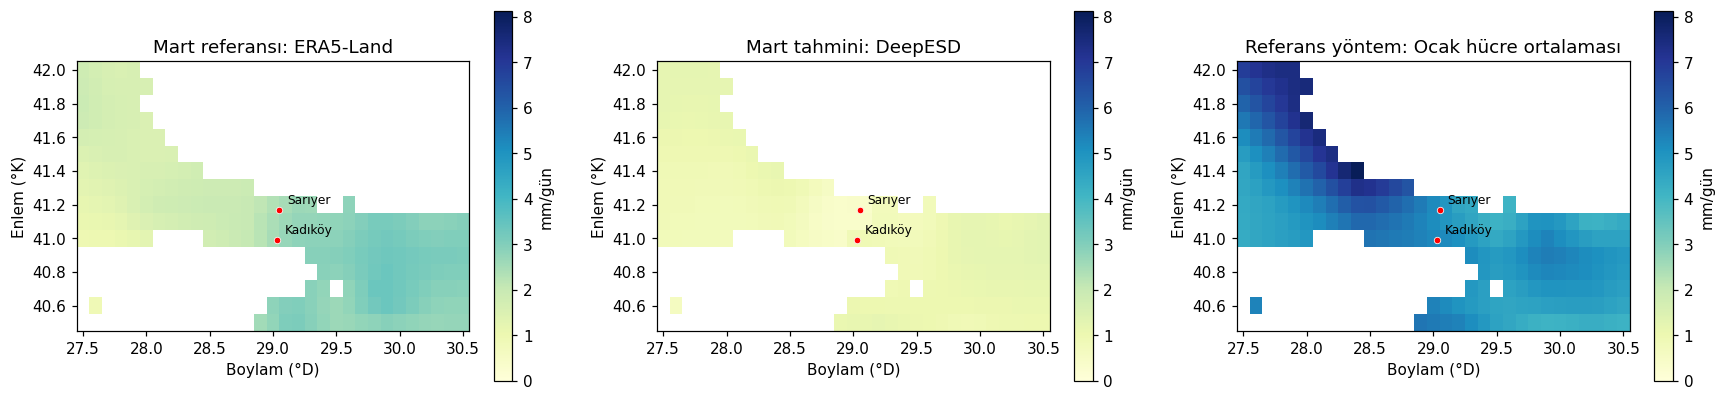

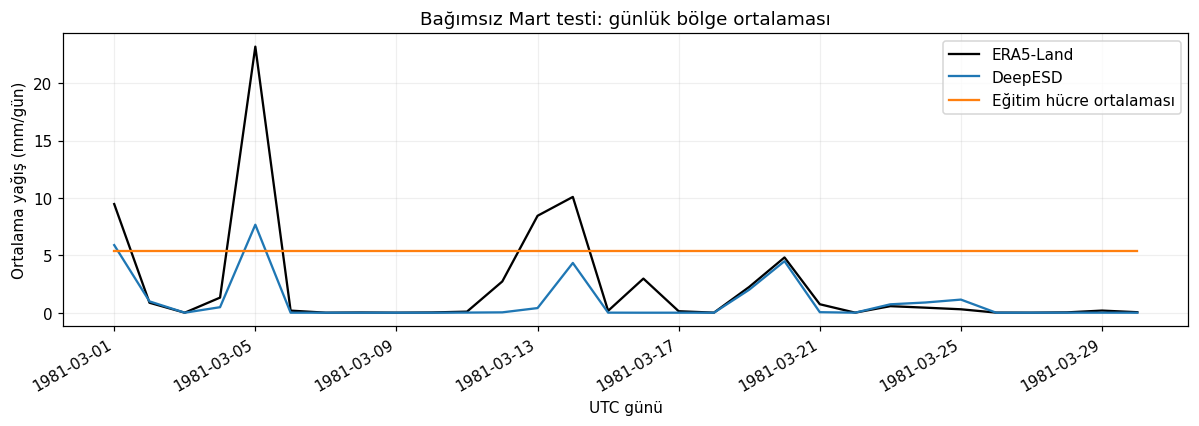

In [10]:
# Ortalama haritalarda tüm yöntemler aynı renk ölçeğini kullanır.
fields = [test_reference.mean('time'), test_predictions['DeepESD'].mean('time'),
          test_predictions['Eğitim hücre ortalaması'].mean('time')]
titles = ['Mart referansı: ERA5-Land', 'Mart tahmini: DeepESD', 'Referans yöntem: Ocak hücre ortalaması']
vmax = max(float(field.max()) for field in fields)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, field, title in zip(axes, fields, titles):
    plot_field(ax, field, title, vmin=0, vmax=vmax)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'test_mean_maps.png', dpi=160, bbox_inches='tight')
plt.show()

# Günlük bölge ortalamaları; yalnız geçerli hedef hücreleri kullanılır.
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test_reference.time, preprocessor.targets(test_reference).mean(axis=1), color='black', label='ERA5-Land')
for name in ['DeepESD', 'Eğitim hücre ortalaması']:
    ax.plot(test_reference.time, preprocessor.targets(test_predictions[name]).mean(axis=1), label=name)
ax.set(xlabel='UTC günü', ylabel='Ortalama yağış (mm/gün)', title='Bağımsız Mart testi: günlük bölge ortalaması')
ax.grid(alpha=.2)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'test_daily_series.png', dpi=160)
plt.show()


Sonuçlar: /Users/onursenturk/downscaling-climate-projections/results/istanbul_1981_q1


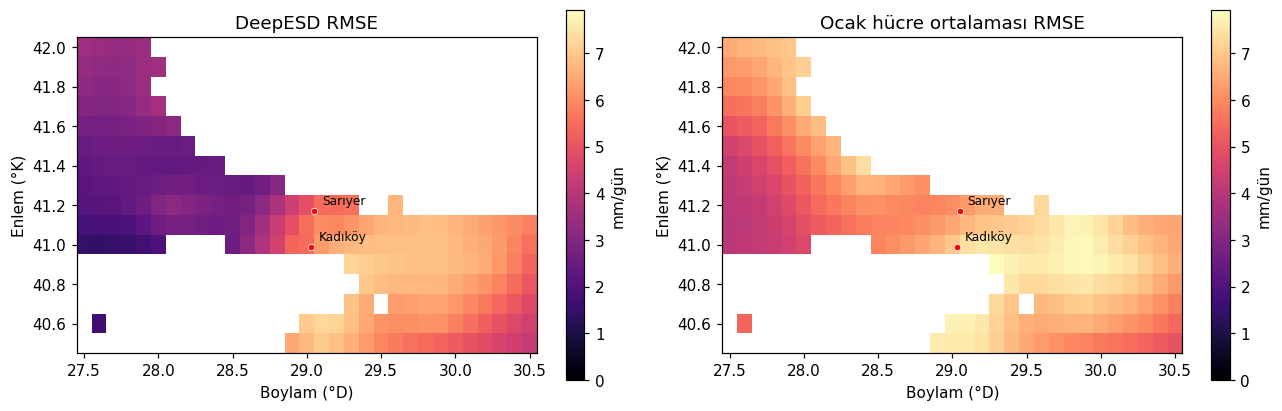

In [11]:
# RMSE: DeepESD ve basit referansın hatalarını aynı ölçekle karşılaştır.
errors = [np.sqrt(((test_predictions[name] - test_reference)**2).mean('time'))
          for name in ['DeepESD', 'Eğitim hücre ortalaması']]
vmax = max(float(field.max()) for field in errors)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, field, title in zip(axes, errors, ['DeepESD RMSE', 'Ocak hücre ortalaması RMSE']):
    plot_field(ax, field, title, cmap='magma', vmin=0, vmax=vmax)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'test_rmse_maps.png', dpi=160, bbox_inches='tight')
plt.show()

report = {
    'training': training_info, 'periods': PERIODS, 'data_audit': data_audit,
    'test_rmse_mm_day': {str(k): float(v) for k, v in comparison.RMSE_mm_day.items()},
    'mse_skill_vs_training_cell_mean': float(skill),
    'model_file': str(MODEL_PATH), 'future_projection_available': False,
}
(RESULTS_DIR / 'run_summary.json').write_text(json.dumps(report, ensure_ascii=False, indent=2))
print('Sonuçlar:', RESULTS_DIR.resolve())


## 7. Sonuçların kapsamı ve sonraki çalışma

**ERA5-Land bağımsız gözlem değildir.** Yağış zorlaması ERA5'ten daha ince ızgaraya aktarılır.
Bu referansla elde edilen başarı, İstanbul'daki gerçek yerel yağış ayrıntılarının öğrenildiğini tek başına göstermez.
İstasyon veya uygun bağımsız gözlemsel referansla ayrıca değerlendirmek gerekir.
[ERA5-Land veri makalesi, bölüm 2.3](https://essd.copernicus.org/articles/13/4349/2021/).

Bu kutu İstanbul çevresini kapsar; idari İstanbul sınır maskesi değildir. Hedef 0,1° ızgara mahalle ölçeğinde gözlem anlamına gelmez.
Girdi 0,25° ızgaradadır. Sarıyer ve Kadıköy nokta değerleri en yakın ızgara merkezinden alınır.

**Gelecek projeksiyonu beklemede.** Mevcut çalışma yalnız tarihsel reanaliz kullanır.
CMIP6 tarihsel/SSP senaryoları, model ve üye seçimi, takvim ve birim uyumu, aynı predictor ızgarasına aktarım,
dağılım farklarının değerlendirilmesi ve çok yıllı doğrulama olmadan gelecek yağış değişimi hesaplanmaz.
Geleceğe ait gözlemsel bir “gerçek” bulunmaz; özgün benchmark'ın gelecekteki RCM referansı burada mevcut değildir.

Veri genişletildiğinde önce dönemleri ve bağımsız değerlendirmeyi yenile; mevsimsel ve yıllık uç değerleri ancak yeterli zaman kapsamıyla ekle.
Özgün U-Net örneği 7×13 girdi ve maskeli 210 çıktı ile uyumlu olmadığından bu çalışan deney akışına dahil edilmemiştir.


In [12]:
print('Gelecek projeksiyonu: BEKLEMEDE — GCM/SSP verisi yok.')
print('Tamamlanan deney: Ocak eğitimi → Şubat model seçimi → bağımsız Mart testi.')
print('Model:', MODEL_PATH)
print('Metrikler:', RESULTS_DIR / 'test_metrics.csv')
print('Tahminler:', RESULTS_DIR / 'test_predictions.nc')


Gelecek projeksiyonu: BEKLEMEDE — GCM/SSP verisi yok.
Tamamlanan deney: Ocak eğitimi → Şubat model seçimi → bağımsız Mart testi.
Model: models/deepesd_istanbul_1981_q1.pt
Metrikler: results/istanbul_1981_q1/test_metrics.csv
Tahminler: results/istanbul_1981_q1/test_predictions.nc


## Kaynaklar ve yeniden üretim

- González-Abad, J. (2026), *Statistical Downscaling of Climate Projections with Deep Learning*, Climate Change AI. [Özgün eğitim deposu](https://github.com/climatechange-ai-tutorials/downscaling-climate-projections).
- [ERA5 basınç seviyesi verileri](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels).
- [ERA5-Land saatlik verileri](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land).
- [ERA5-Land veri makalesi](https://doi.org/10.5194/essd-13-4349-2021).

Çevrimdışı otomatik kontroller: `python -m unittest discover -s tests -v`.
Bu notebook'un tüm Python hücrelerini yeni süreçte yürütmek ve çıktıları kaydetmek: `python scripts/run_notebook.py --write`.
Ham veri, model, sonuçlar ve düzenleme öncesi yedekler Git dışında tutulur. README ortam kurulumu ve çıktı dosyalarını açıklar.
